<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1196 | Val: 336 | Test: 189


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 4, accumulation steps = 6 (effective batch size ≈ 24, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

# ConvNeXt's classifier is Sequential(LayerNorm2d, Flatten, Linear) — swap
# out just the final Linear layer for our (optionally deeper) classifier
# head, same as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).
[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 0.9231 acc 0.678 | val loss 0.5934 acc 0.798 *
[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.6223 acc 0.793 | val loss 0.4896 acc 0.801 *
[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.4750 acc 0.835 | val loss 0.5568 acc 0.792
[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.4737 acc 0.822 | val loss 0.3962 acc 0.818 *
[ConvNeXt-Tiny] Epoch   5/100 | LR: 5.00e-05 | train loss 0.3926 acc 0.860 | val loss 0.3498 acc 0.854 *
[ConvNeXt-Tiny] Epoch   6/100 | LR: 5.00e-05 | train loss 0.3561 acc 0.870 | val loss 0.3498 acc 0.839 *
[ConvNeXt-Tiny] Epoch   7/100 | LR: 5.00e-05 | train loss 0.3337 acc 0.877 | val loss 0.3404 acc 0.851 *
[ConvNeXt-Tiny] Epoch   8/100 | LR: 5.00e-05 | train loss 0.2859 acc 0.901 | val loss 0.4047 acc 0.833
[ConvNeXt-Tiny] Epoch   9/100 | LR: 5.00e-

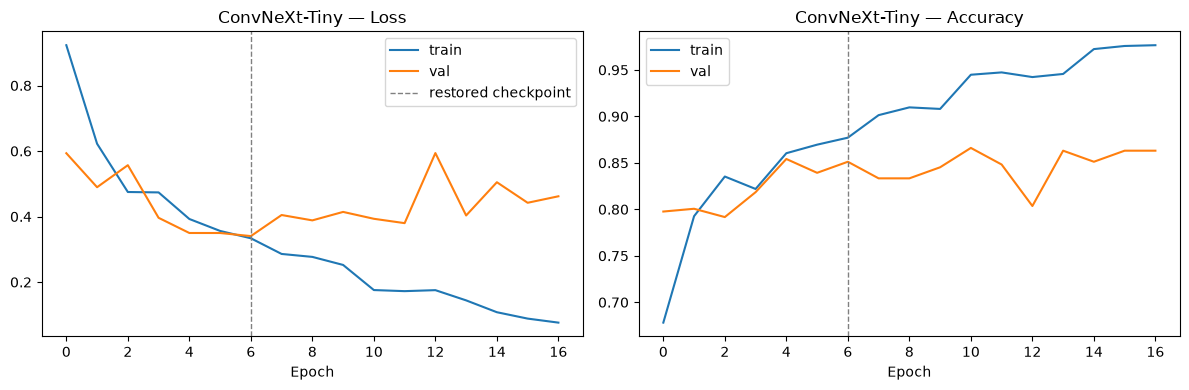

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.825


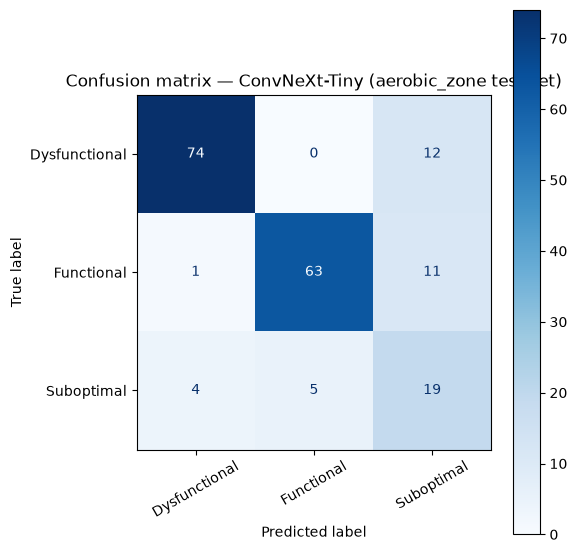

               precision    recall  f1-score   support

Dysfunctional      0.937     0.860     0.897        86
   Functional      0.926     0.840     0.881        75
   Suboptimal      0.452     0.679     0.543        28

     accuracy                          0.825       189
    macro avg      0.772     0.793     0.774       189
 weighted avg      0.861     0.825     0.838       189



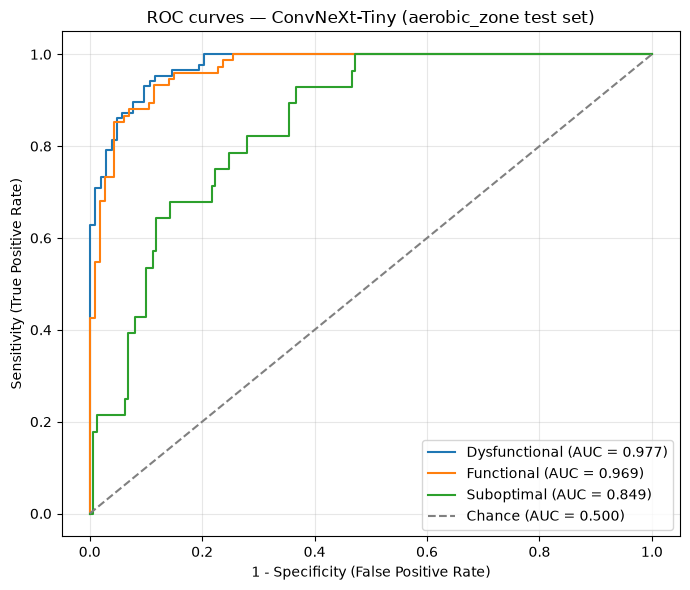

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.977
  Functional     : 0.969
  Suboptimal     : 0.849

Mean AUC: 0.931


(np.float64(0.8253968253968254),
 {'Dysfunctional': 0.9767441860465116,
  'Functional': 0.9687719298245614,
  'Suboptimal': 0.8489352262644188})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_aerobic_zone_convnext_tiny.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
